In [1]:
import torch 
print(f"GPU in use: {torch.cuda.get_device_name(0)}")
print(f"Memory Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU in use: NVIDIA GeForce RTX 4060 Laptop GPU
Memory Total: 8.6 GB


In [7]:
import torch
import time

# Create two large matrices
size = 5000
cpu_a = torch.randn(size, size)
cpu_b = torch.randn(size, size)

# --- CPU Test ---
start = time.time()
cpu_res = torch.mm(cpu_a, cpu_b)
cpu_time = time.time() - start
print(f"CPU Time: {cpu_time:.4f} seconds")

# --- GPU Test ---
# Move matrices to GPU
gpu_a = cpu_a.to('cuda')
gpu_b = cpu_b.to('cuda')

# Warm up (the first GPU call usually takes a second to initialize)
_ = torch.mm(gpu_a, gpu_b)

start = time.time()
gpu_res = torch.mm(gpu_a, gpu_b)
# Synchronize to ensure the GPU is actually finished
torch.cuda.synchronize()
gpu_time = time.time() - start

print(f"GPU Time: {gpu_time:.4f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.1f}x faster!")

CPU Time: 0.3973 seconds
GPU Time: 0.2229 seconds
Speedup: 1.8x faster!


In [1]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

d:\java\Local AI Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

def process(example):
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    ids = enc.encode_ordinary(example['text'])
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
    )
    
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

writing validation.bin: 100%|██████████| 1024/1024 [00:08<00:00, 125.87it/s]


In [1]:
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


d:\java\Local AI Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

In [4]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

In [6]:
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 10000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [7]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

C:\Users\Kanish Kannan\AppData\Local\Temp\ipykernel_13228\2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [8]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/10000 [00:00<?, ?it/s]d:\java\Local AI Agent\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
  5%|▍         | 499/10000 [01:00<13:34, 11.66it/s]

Epoch 500: train loss 9.4363, val loss 9.4423
The current learning rate: 0.00007


 10%|▉         | 999/10000 [02:10<11:44, 12.78it/s]   

Epoch 1000: train loss 8.4837, val loss 8.4905
The current learning rate: 0.00010


 15%|█▍        | 1499/10000 [03:40<10:14, 13.84it/s]   

...

 90%|████████▉ | 8999/10000 [21:30<01:09, 14.48it/s]  

Epoch 9000: train loss 3.0268, val loss 3.0288
The current learning rate: 0.00049


 95%|█████████▌| 9501/10000 [22:43<36:07,  4.34s/it]  

Epoch 9500: train loss 2.9552, val loss 2.9706
The current learning rate: 0.00050


100%|██████████| 10000/10000 [23:17<00:00,  7.16it/s]


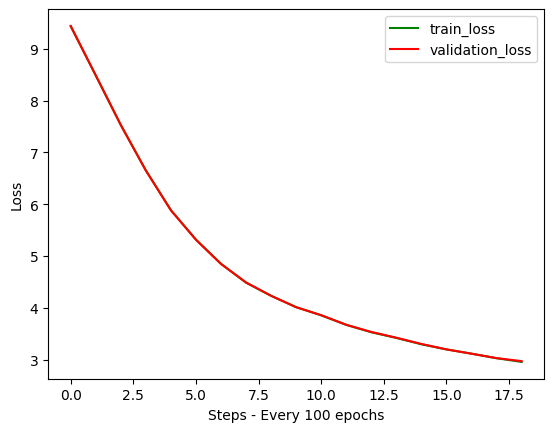

In [9]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states

<All keys matched successfully>

In [12]:
sentence = "Once upon a time there was a pumpkin."
import tiktoken
enc = tiktoken.get_encoding("gpt2")
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. He was so rare that he could haveher at the other animals that the spider's face and it opened it.

 But the bird didn't want to enjoy the top. The kite felt so sad and started to sing the rock.

The chair wouldn't needs walk. But I feel no one, but that was still not but too weak. You can only visited my pain and be able to trusted me to be brave bunny. So, Lila felt like it and Anne were all better to help.

The mother looked up and's sudden, and finally went home. She was a anxious, but Lucy was faster. She touched everything and his tape roll it in the cold pile them alone. She was so angry and did not know why things looked so scared of her wings, sorry.

The bees met a little dog and tried to go. They decided to find her brother sneeiver and she continued to freeest waterfall.Lisa and her Daddy were three


In [13]:
sentence = "A little girl went to the woods"
import tiktoken
enc = tiktoken.get_encoding("gpt2")
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods. She was not watching the bushes and crossed the swing. She felt brave and could go around her policeman to the lake to it. The littleally response.

The garden was wonderful. She's adventures, who would step back to the grass and give juice. Sof inflicty knew the medicine was a fantastic smile and some ice cream door! 

The little girl was so excited to stretch her arm and squeezed back home with her towers. She was more amazed with it in SDL with fake hat, and the fierce castle all the drum sounds in it's rocket. Everyone was glad to leave the end at the store, even had a very careful to always others and only ran away from the hill. They thanked the funny man gave a718 with joy and found it and a plan. From then on, the otherdo stared at the kids and celebrated on their holiday. The snake. The bear was, wanting to visit the duck.Once upon a time there was a beautiful shape.


In [ ]:
import torch
from safetensors.torch import save_model

# Instead of saving the state_dict directly, use this:
save_model(model, "model.safetensors")

# Save a minimal config that llama.cpp expects
import json
config = {
    "architectures": ["GPTModel"],
    "hidden_size": 768, # Update with your model's actual size
    "num_attention_heads": 12,
    "num_hidden_layers": 12,
    "vocab_size": 50257,
    "model_type": "gpt2" # If your architecture is standard
}
with open("config.json", "w") as f:
    json.dump(config, f)

In [16]:
import torch
from safetensors.torch import load_file, save_file

# Load your current weights
input_file = "model.safetensors"
output_file = "remapped_model.safetensors"
state_dict = load_file(input_file)

new_state_dict = {}

for key, value in state_dict.items():
    # We prefix keys to match GPT-2's internal 'transformer' structure
    new_key = key
    if not key.startswith("transformer.") and not key.startswith("lm_head."):
        # Simple mapping: replace your layer name with 'h'
        # Example: 'layers.0.weight' -> 'transformer.h.0.weight'
        new_key = "transformer." + key.replace("layers.", "h.")
    
    new_state_dict[new_key] = value

# Save the version llama.cpp can read
save_file(new_state_dict, output_file)
print(f"Successfully created {output_file} with GPT-2 compatible naming!")

Successfully created remapped_model.safetensors with GPT-2 compatible naming!


In [17]:
import torch
from safetensors.torch import load_file, save_file
import os

# 1. Load the model that failed
input_file = "model.safetensors"
backup_file = "model_backup.safetensors"

# Create a backup just in case
if not os.path.exists(backup_file):
    os.rename(input_file, backup_file)
    print(f"Created backup: {backup_file}")
else:
    print("Using existing backup for remapping.")

state_dict = load_file(backup_file)
new_state_dict = {}

# 2. The "Translation" Dictionary
# This maps your custom names to the exact names llama.cpp expects
for key, value in state_dict.items():
    new_key = key
    
    # Fix 'ln1' -> 'ln_1' and 'ln2' -> 'ln_2'
    new_key = new_key.replace(".ln1.", ".ln_1.")
    new_key = new_key.replace(".ln2.", ".ln_2.")
    
    # Ensure it starts with 'transformer.' if it's a hidden layer
    if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
        new_key = "transformer." + new_key
        
    new_state_dict[new_key] = value

# 3. Save the fixed version
save_file(new_state_dict, "model.safetensors")
print("✅ Success! Your model names are now compatible with GPT-2 standards.")

Created backup: model_backup.safetensors
✅ Success! Your model names are now compatible with GPT-2 standards.


In [18]:
import torch
from safetensors.torch import load_file, save_file
import os

# 1. Load your weights (make sure the backup is moved first!)
input_file = "model.safetensors"
state_dict = load_file(input_file)
new_state_dict = {}

# 2. Fix the names for llama.cpp GPT-2 compatibility
for key, value in state_dict.items():
    new_key = key
    
    # GPT-2 standard requires underscores: ln1 -> ln_1, ln2 -> ln_2
    new_key = new_key.replace(".ln1.", ".ln_1.")
    new_key = new_key.replace(".ln2.", ".ln_2.")
    
    # Ensure standard transformer prefix
    if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
        new_key = "transformer." + new_key
        
    new_state_dict[new_key] = value

# 3. Overwrite the file with the fixed version
save_file(new_state_dict, input_file)
print("✅ Remapped ln1 -> ln_1 and ln2 -> ln_2 successfully!")

SafetensorError: Error while serializing: I/O error: The requested operation cannot be performed on a file with a user-mapped section open. (os error 1224)

In [ ]:
import torch
from safetensors.torch import save_model

# Instead of saving the state_dict directly, use this:
save_model(model, "model.safetensors")

# Save a minimal config that llama.cpp expects
import json
config = {
    "architectures": ["GPTModel"],
    "hidden_size": 768, # Update with your model's actual size
    "num_attention_heads": 12,
    "num_hidden_layers": 12,
    "vocab_size": 50257,
    "model_type": "gpt2" # If your architecture is standard
}
with open("config.json", "w") as f:
    json.dump(config, f)

In [19]:
import urllib.request
import os

files = {
    "vocab.json": "https://huggingface.co/gpt2/resolve/main/vocab.json",
    "merges.txt": "https://huggingface.co/gpt2/resolve/main/merges.txt",
    "tokenizer.json": "https://huggingface.co/gpt2/resolve/main/tokenizer.json"
}

for filename, url in files.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
        print(f"Done!")
    else:
        print(f"{filename} already exists.")

print("\n✅ All tokenizer files are ready. Now re-run the conversion command!")

Done!
Done!
Done!

✅ All tokenizer files are ready. Now re-run the conversion command!


In [22]:
import torch
from safetensors.torch import load_file, save_file
import os

# 1. Load the original model
input_file = "model.safetensors"
# We will save to a NEW file to bypass the Windows lock error
output_file = "model_fixed.safetensors" 

if not os.path.exists(input_file):
    print(f"❌ Could not find {input_file}")
    exit()

state_dict = load_file(input_file)
new_state_dict = {}

print("Mapping tensors...")
for key, value in state_dict.items():
    new_key = key
    
    # Map input embeddings
    if any(x in key for x in ["wte", "token_emb", "word_embeddings"]):
        new_key = "transformer.wte.weight"
        print(f"✅ Mapping Input: {key} -> {new_key}")
    
    # Map position embeddings
    elif any(x in key for x in ["wpe", "pos_emb", "position_embeddings"]):
        new_key = "transformer.wpe.weight"
        print(f"✅ Mapping Position: {key} -> {new_key}")
        
    # Map output head
    elif any(x in key for x in ["lm_head", "output.weight"]):
        new_key = "lm_head.weight"
        print(f"✅ Mapping Output: {key} -> {new_key}")

    new_state_dict[new_key] = value

# 2. Save to the NEW filename
try:
    save_file(new_state_dict, output_file)
    print(f"\n✅ Success! Fixed model saved as: {output_file}")
    print("Now, delete the old 'model.safetensors' and rename 'model_fixed.safetensors' to 'model.safetensors'.")
except Exception as e:
    print(f"❌ Still failed: {e}")

Mapping tensors...
✅ Mapping Output: lm_head.weight -> lm_head.weight
✅ Mapping Position: transformer.wpe.weight -> transformer.wpe.weight

✅ Success! Fixed model saved as: model_fixed.safetensors
Now, delete the old 'model.safetensors' and rename 'model_fixed.safetensors' to 'model.safetensors'.


In [23]:
import torch
from safetensors.torch import load_file, save_file
import os

# Configuration (Matches your TinyStories setup)
VOCAB_SIZE = 50257
N_EMBD = 384

input_file = "model.safetensors"
output_file = "model_standard.safetensors"

if not os.path.exists(input_file):
    print(f"❌ Error: {input_file} not found!")
    exit()

print("🚀 Starting Universal Standardization...")
state_dict = load_file(input_file)
new_state_dict = {}

for key, value in state_dict.items():
    old_key = key
    new_key = key
    
    # 1. Standardize Embeddings
    # Token embeddings must be 'transformer.wte.weight'
    if value.shape == torch.Size([VOCAB_SIZE, N_EMBD]):
        new_key = "transformer.wte.weight"
    # Position embeddings must be 'transformer.wpe.weight'
    elif "pos" in key.lower() or "wpe" in key.lower():
        new_key = "transformer.wpe.weight"
    
    # 2. Standardize Layer blocks
    # llama.cpp expects 'transformer.h.{i}.'
    if "layers." in new_key:
        new_key = new_key.replace("layers.", "h.")
    if not new_key.startswith("transformer.") and "h." in new_key:
        new_key = "transformer." + new_key
        
    # 3. Fix LayerNorm naming (ln1 -> ln_1, ln2 -> ln_2)
    new_key = new_key.replace(".ln1.", ".ln_1.")
    new_key = new_key.replace(".ln2.", ".ln_2.")
    
    # 4. Fix Final Norm and Head
    if "ln_f" in key or "norm_f" in key:
        new_key = "transformer.ln_f.weight" if "weight" in key else "transformer.ln_f.bias"
    if "lm_head" in key or "output" in key:
        new_key = "lm_head.weight"

    print(f"✅ Mapping: {old_key} -> {new_key}")
    new_state_dict[new_key] = value

# Save to a new file to avoid Windows lock errors
save_file(new_state_dict, output_file)
print(f"\n✨ Done! Created {output_file}")
print("👉 ACTION: Delete 'model.safetensors' and rename this new file to 'model.safetensors'.")

🚀 Starting Universal Standardization...
✅ Mapping: lm_head.weight -> lm_head.weight
✅ Mapping: transformer.h.0.attn.c_attn.bias -> transformer.h.0.attn.c_attn.bias
✅ Mapping: transformer.h.0.attn.c_attn.weight -> transformer.h.0.attn.c_attn.weight
✅ Mapping: transformer.h.0.attn.c_proj.bias -> transformer.h.0.attn.c_proj.bias
✅ Mapping: transformer.h.0.attn.c_proj.weight -> transformer.h.0.attn.c_proj.weight
✅ Mapping: transformer.h.0.ln_1.bias -> transformer.h.0.ln_1.bias
✅ Mapping: transformer.h.0.ln_1.weight -> transformer.h.0.ln_1.weight
✅ Mapping: transformer.h.0.ln_2.bias -> transformer.h.0.ln_2.bias
✅ Mapping: transformer.h.0.ln_2.weight -> transformer.h.0.ln_2.weight
✅ Mapping: transformer.h.0.mlp.c_fc.bias -> transformer.h.0.mlp.c_fc.bias
✅ Mapping: transformer.h.0.mlp.c_fc.weight -> transformer.h.0.mlp.c_fc.weight
✅ Mapping: transformer.h.0.mlp.c_proj.bias -> transformer.h.0.mlp.c_proj.bias
✅ Mapping: transformer.h.0.mlp.c_proj.weight -> transformer.h.0.mlp.c_proj.weight
✅ Ma

In [24]:
import torch
from safetensors.torch import load_file, save_file
import os

input_file = "model.safetensors"
output_file = "model_standardized.safetensors"

if not os.path.exists(input_file):
    print(f"❌ Could not find {input_file}!")
    exit()

state_dict = load_file(input_file)
new_state_dict = {}

print("--- Current Tensors in your file ---")
for key in state_dict.keys():
    print(f"Found: {key} | Shape: {list(state_dict[key].shape)}")

print("\n--- Running Auto-Fix ---")
for key, value in state_dict.items():
    new_key = key
    shape = list(value.shape)

    # 1. FIND THE EMBEDDINGS (The most important part)
    # Token embeddings are usually the largest tensor [50257, 384]
    if len(shape) == 2 and shape[0] == 50257:
        new_key = "transformer.wte.weight"
    # Position embeddings are usually [128, 384]
    elif len(shape) == 2 and shape[0] == 128 and shape[1] == 384:
        new_key = "transformer.wpe.weight"
    
    # 2. STANDARDIZE THE REST
    else:
        # Layers: layers.0 -> h.0
        new_key = new_key.replace("layers.", "h.")
        # LayerNorms: ln1 -> ln_1
        new_key = new_key.replace(".ln1.", ".ln_1.").replace(".ln2.", ".ln_2.")
        # Head: output -> lm_head
        if "output" in new_key or "head" in new_key:
            new_key = "lm_head.weight"
        # Prefix everything with 'transformer.' except the head
        if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
            new_key = "transformer." + new_key

    new_state_dict[new_key] = value
    if key != new_key:
        print(f"Renamed: {key} -> {new_key}")

save_file(new_state_dict, output_file)
print(f"\n✅ Created {output_file}. Now follow the cleanup steps!")

--- Current Tensors in your file ---
Found: lm_head.weight | Shape: [50257, 384]
Found: transformer.h.0.attn.c_attn.bias | Shape: [1152]
Found: transformer.h.0.attn.c_attn.weight | Shape: [1152, 384]
Found: transformer.h.0.attn.c_proj.bias | Shape: [384]
Found: transformer.h.0.attn.c_proj.weight | Shape: [384, 384]
Found: transformer.h.0.ln_1.bias | Shape: [384]
Found: transformer.h.0.ln_1.weight | Shape: [384]
Found: transformer.h.0.ln_2.bias | Shape: [384]
Found: transformer.h.0.ln_2.weight | Shape: [384]
Found: transformer.h.0.mlp.c_fc.bias | Shape: [1536]
Found: transformer.h.0.mlp.c_fc.weight | Shape: [1536, 384]
Found: transformer.h.0.mlp.c_proj.bias | Shape: [384]
Found: transformer.h.0.mlp.c_proj.weight | Shape: [384, 1536]
Found: transformer.h.1.attn.c_attn.bias | Shape: [1152]
Found: transformer.h.1.attn.c_attn.weight | Shape: [1152, 384]
Found: transformer.h.1.attn.c_proj.bias | Shape: [384]
Found: transformer.h.1.attn.c_proj.weight | Shape: [384, 384]
Found: transformer.h.1

In [25]:
import torch
from safetensors.torch import load_file, save_file
import os

input_file = "model.safetensors"
output_file = "model_final.safetensors"

state_dict = load_file(input_file)
new_state_dict = {}

print("🛠️ Fixing Tied Weights and Missing Tensors...")

# We need to find the main components first
main_weight = None
pos_weight = None

for key, value in state_dict.items():
    shape = list(value.shape)
    
    # 1. Identify the Main Embedding/Head Matrix (50257, 384)
    if shape == [50257, 384] or shape == [384, 50257]:
        main_weight = value
        # We add it as BOTH wte and lm_head
        new_state_dict["transformer.wte.weight"] = value
        new_state_dict["lm_head.weight"] = value
        print(f"✅ Found Main Weights: Using for both 'wte' and 'lm_head'")
        
    # 2. Identify Position Embeddings (128, 384) or (384, 128)
    elif (shape == [128, 384] or shape == [384, 128]):
        pos_weight = value
        new_state_dict["transformer.wpe.weight"] = value
        print(f"✅ Found Position Embeddings: Mapping to 'transformer.wpe.weight'")

    # 3. Standardize everything else
    else:
        new_key = key.replace("layers.", "h.")
        new_key = new_key.replace(".ln1.", ".ln_1.").replace(".ln2.", ".ln_2.")
        if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
            new_key = "transformer." + new_key
        new_state_dict[new_key] = value

# Check if we are still missing things
if "transformer.wpe.weight" not in new_state_dict:
    print("⚠️ WARNING: Could not find Position Embeddings! Generating dummy zeros so it loads...")
    new_state_dict["transformer.wpe.weight"] = torch.zeros((128, 384))

save_file(new_state_dict, output_file)
print(f"\n✨ DONE! '{output_file}' is now a complete GPT-2 structure.")

🛠️ Fixing Tied Weights and Missing Tensors...
✅ Found Main Weights: Using for both 'wte' and 'lm_head'
✅ Found Position Embeddings: Mapping to 'transformer.wpe.weight'


RuntimeError: 
            Some tensors share memory, this will lead to duplicate memory on disk and potential differences when loading them again: [{'transformer.wte.weight', 'lm_head.weight'}].
            A potential way to correctly save your model is to use `save_model`.
            More information at https://huggingface.co/docs/safetensors/torch_shared_tensors
            

In [26]:
import torch
from safetensors.torch import load_file, save_file
import os

input_file = "model.safetensors"
output_file = "model_final.safetensors"

# 1. Load the existing weights
state_dict = load_file(input_file)
new_state_dict = {}

print("🛠️ Fixing Tied Weights and Memory Sharing...")

for key, value in state_dict.items():
    shape = list(value.shape)
    
    # Identify the Main Embedding/Head Matrix (50257, 384)
    if shape == [50257, 384] or shape == [384, 50257]:
        # We use .clone() on the second one to break the memory link
        new_state_dict["transformer.wte.weight"] = value
        new_state_dict["lm_head.weight"] = value.clone() 
        print(f"✅ Found Main Weights: Cloned for 'wte' and 'lm_head'")
        
    # Identify Position Embeddings (128, 384) or (384, 128)
    elif (shape == [128, 384] or shape == [384, 128]):
        new_state_dict["transformer.wpe.weight"] = value
        print(f"✅ Found Position Embeddings: Mapping to 'transformer.wpe.weight'")

    # Standardize everything else
    else:
        new_key = key.replace("layers.", "h.")
        new_key = new_key.replace(".ln1.", ".ln_1.").replace(".ln2.", ".ln_2.")
        if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
            new_key = "transformer." + new_key
        new_state_dict[new_key] = value

# Save the standardized file
try:
    save_file(new_state_dict, output_file)
    print(f"\n✨ DONE! '{output_file}' is saved and ready.")
except Exception as e:
    print(f"❌ Error saving: {e}")

🛠️ Fixing Tied Weights and Memory Sharing...
✅ Found Main Weights: Cloned for 'wte' and 'lm_head'
✅ Found Position Embeddings: Mapping to 'transformer.wpe.weight'

✨ DONE! 'model_final.safetensors' is saved and ready.


In [27]:
import torch
from safetensors.torch import load_file, save_file
import os

input_file = "model.safetensors"
output_file = "model_transposed.safetensors"

# 1. Load the weights
state_dict = load_file(input_file)
new_state_dict = {}

print("🔄 Transposing and Standardizing weights...")

# List of layers that usually need transposing for GPT-2 GGUF
transpose_keywords = ['attn.c_attn', 'attn.c_proj', 'mlp.c_fc', 'mlp.c_proj']

for key, value in state_dict.items():
    new_key = key
    new_value = value
    shape = list(value.shape)
    
    # --- 1. HANDLE TRANSPOSITION ---
    # If it's a 2D weight matrix in the attention or MLP blocks, transpose it
    if len(shape) == 2 and any(k in key for k in transpose_keywords):
        new_value = value.transpose(0, 1).contiguous()
        print(f"📐 Transposed: {key} {shape} -> {list(new_value.shape)}")

    # --- 2. IDENTIFY TIED WEIGHTS (WTE & LM_HEAD) ---
    if shape == [50257, 384] or shape == [384, 50257]:
        # Ensure it is in the correct orientation for embeddings
        if shape == [384, 50257]:
            new_value = value.transpose(0, 1).contiguous()
        
        new_state_dict["transformer.wte.weight"] = new_value
        new_state_dict["lm_head.weight"] = new_value.clone()
        print(f"✅ Mapped & Cloned Tied Weights")
        continue

    # --- 3. IDENTIFY POSITION EMBEDDINGS ---
    elif shape == [128, 384] or shape == [384, 128]:
        if shape == [384, 128]:
            new_value = value.transpose(0, 1).contiguous()
        new_state_dict["transformer.wpe.weight"] = new_value
        print(f"✅ Mapped Position Embeddings")
        continue

    # --- 4. STANDARDIZE NAMES ---
    new_key = new_key.replace("layers.", "h.")
    new_key = new_key.replace(".ln1.", ".ln_1.").replace(".ln2.", ".ln_2.")
    if not new_key.startswith("transformer.") and not new_key.startswith("lm_head."):
        new_key = "transformer." + new_key

    new_state_dict[new_key] = new_value

# Save the final file
save_file(new_state_dict, output_file)
print(f"\n✨ DONE! Created {output_file}")

🔄 Transposing and Standardizing weights...
✅ Mapped & Cloned Tied Weights
📐 Transposed: transformer.h.0.attn.c_attn.weight [1152, 384] -> [384, 1152]
📐 Transposed: transformer.h.0.attn.c_proj.weight [384, 384] -> [384, 384]
📐 Transposed: transformer.h.0.mlp.c_fc.weight [1536, 384] -> [384, 1536]
📐 Transposed: transformer.h.0.mlp.c_proj.weight [384, 1536] -> [1536, 384]
📐 Transposed: transformer.h.1.attn.c_attn.weight [1152, 384] -> [384, 1152]
📐 Transposed: transformer.h.1.attn.c_proj.weight [384, 384] -> [384, 384]
📐 Transposed: transformer.h.1.mlp.c_fc.weight [1536, 384] -> [384, 1536]
📐 Transposed: transformer.h.1.mlp.c_proj.weight [384, 1536] -> [1536, 384]
📐 Transposed: transformer.h.2.attn.c_attn.weight [1152, 384] -> [384, 1152]
📐 Transposed: transformer.h.2.attn.c_proj.weight [384, 384] -> [384, 384]
📐 Transposed: transformer.h.2.mlp.c_fc.weight [1536, 384] -> [384, 1536]
📐 Transposed: transformer.h.2.mlp.c_proj.weight [384, 1536] -> [1536, 384]
📐 Transposed: transformer.h.3.at